# PINN Solving Foreward 1D Burgers Equation (PyTorch)

This notebook solves the Burgers equation using a Physics-Informed Neural Network (PINN).

## Burgers' Equation

We consider the one-dimensional viscous Burgers' equation

$$
\frac{\partial u}{\partial t}
+
u\frac{\partial u}{\partial x}
=
\nu\frac{\partial^2 u}{\partial x^2},
\qquad
x\in[-1,1],\;
t\in[0,1],
$$

where

- $u(x,t)$ is the velocity field,
- $\nu$ is the kinematic viscosity (unknown for the inverse problem).

### Initial Condition

The initial condition is

$$
u(x,0) = -\sin(\pi x),
\qquad
-1 \le x \le 1.
$$

### Boundary Conditions

Homogeneous Dirichlet boundary conditions are imposed at both ends of the domain,

$$
u(-1,t)=0,
\qquad
u(1,t)=0,
\qquad
0 \le t \le 1.
$$

### Objective

The goal of the forward problem is to learn

- the solution $u(x,t)$, 

enforcing the Burgers' equation and initail and boundary conditions through the physics-informed neural network (PINN).

# Analytical Solution via the Hopf–Cole Transformation

https://en.wikipedia.org/wiki/Burgers%27_equation

To generate the synthetic training data, we compute the analytical solution of Burgers' equation using the **Hopf–Cole transformation**. This transformation converts the nonlinear Burgers' equation into the linear heat equation, which has a known integral solution.

## Hopf–Cole Transformation

Introduce a new function $\phi(x,t)$ such that

$$
u(x,t)=-2\nu\frac{\partial}{\partial x}\ln\phi(x,t)
=-2\nu\frac{\phi_x}{\phi}.
$$

Substituting this expression into Burgers' equation,

$$
u_t+u\,u_x=\nu u_{xx},
$$

shows that $\phi(x,t)$ satisfies the one-dimensional heat equation

$$
\phi_t=\nu\phi_{xx}.
$$

The solution can therefore be written as a convolution with the Gaussian heat kernel.

## Analytical Solution

For the initial condition

$$
u(x,0)=-\sin(\pi x),
$$

the Hopf–Cole solution is

$$
u(x,t)=
-\frac{
\displaystyle
\int_{-\infty}^{\infty}
\sin\!\left(\pi(x-\eta)\right)
\exp\!\left[
-\frac{\cos\!\left(\pi(x-\eta)\right)}
{2\pi\nu}
-\frac{\eta^2}{4\nu t}
\right]
d\eta
}
{
\displaystyle
\int_{-\infty}^{\infty}
\exp\!\left[
-\frac{\cos\!\left(\pi(x-\eta)\right)}
{2\pi\nu}
-\frac{\eta^2}{4\nu t}
\right]
d\eta
}.
$$

## Change of Variables

Introduce

$$
\eta=2\sqrt{\nu t}\,q,
$$

so that

$$
d\eta=2\sqrt{\nu t}\,dq,
$$

and

$$
\frac{\eta^2}{4\nu t}=q^2.
$$

The solution becomes

$$
u(x,t)=
-\frac{
\displaystyle
\int_{-\infty}^{\infty}
2\sqrt{\nu t}\,
\sin\!\left(\pi(x-cq)\right)
\exp\!\left(
-\frac{\cos(\pi(x-cq))}{2\pi\nu}
\right)
e^{-q^2}\,dq
}{
\displaystyle
\int_{-\infty}^{\infty}
2\sqrt{\nu t}\,
\exp\!\left(
-\frac{\cos(\pi(x-cq))}{2\pi\nu}
\right)
e^{-q^2}\,dq
},
$$

where

$$
c=2\sqrt{\nu t}.
$$

## Gauss–Hermite Quadrature

Since both integrals have the form

$$
\int_{-\infty}^{\infty}
e^{-q^2}f(q)\,dq,
$$

they can be accurately approximated using Gauss–Hermite quadrature,

$$
\int_{-\infty}^{\infty}
e^{-q^2}f(q)\,dq
\approx
\sum_{i=1}^{N_q}w_i\,f(q_i),
$$

where

- $q_i$ are the Gauss–Hermite quadrature nodes,
- $w_i$ are the corresponding quadrature weights,
- $N_q=32$ in this implementation.

The numerical solution is therefore computed as

$$
u(x,t)\approx
-\frac{
\displaystyle
\sum_{i=1}^{N_q}
w_i\,c\,
\sin\!\left(\pi(x-cq_i)\right)
\exp\!\left(
-\frac{\cos(\pi(x-cq_i))}
{2\pi\nu}
\right)
}
{
\displaystyle
\sum_{i=1}^{N_q}
w_i\,c\,
\exp\!\left(
-\frac{\cos(\pi(x-cq_i))}
{2\pi\nu}
\right)
}.
$$

This quadrature solution is evaluated on a dense $(x,t)$ grid to produce the reference solution `u_quad`, which is then used to generate the synthetic measurement data for training and validating the inverse PINN.

In [1]:
"""
Import libraries and specify device
"""

import torch
import torch.nn as nn
import numpy as np
from scipy.stats.qmc import LatinHypercube
# Generate PDE collocation points using Latin Hypercube Sampling (LHS).
# LHS distributes points more uniformly over the space-time domain than
# purely random sampling, reducing clusters and empty regions. This helps
# the PINN enforce the PDE throughout the entire domain while retaining
# the benefits of random sampling.

from numpy.polynomial.hermite import hermgauss  #for Hermit Quadrature
import matplotlib.pyplot as plt

device = torch.device("cuda:2" if torch.cuda.is_available() else "cpu")
print('device is ', device)


device is  cuda:2


## Analytical solution

x.shape:  (400,)
t.shape:  (100,)
u_quad.shape:  (400, 100)


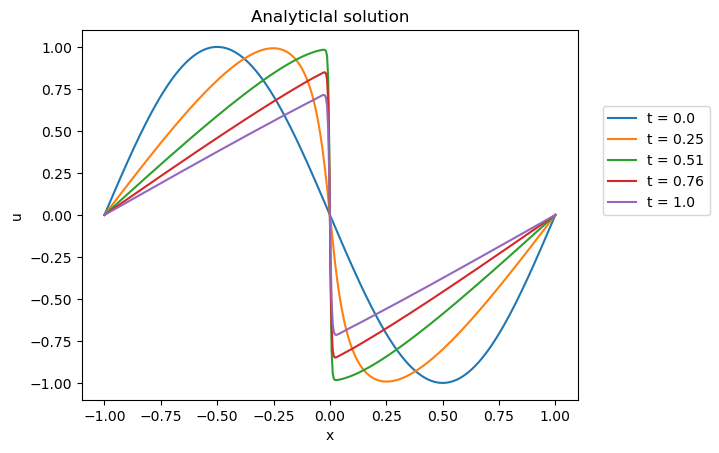

In [2]:
"""
Analytical solution via the Hopf-Cole Transformation and Gauss-Hermit Quadrature
"""

####################################################
# Parameters
####################################################

nu = 0.01/np.pi

x0 = -1.0
xL = 1.0

t0 = 0.0
tf = 1.0

Nx = 400
Nt = 100

x = np.linspace(x0, xL, Nx)
t = np.linspace(t0, tf, Nt)

####################################################
# Gauss-Hermite quadrature
####################################################

quad_order = 32

q, w = hermgauss(quad_order)

####################################################
# Analytical solution
####################################################

u_quad = np.zeros((Nx, Nt), dtype=np.float32)

for j in range(Nt):
    if t[j] == 0.0:
        u_quad[:, j] = -np.sin(np.pi*x)  ## initial condition
        continue

    c = 2*np.sqrt(nu*t[j])

    for i in range(Nx):
        numerator = 0.0
        denominator = 0.0
        for k in range(quad_order):
            xi = x[i] - c*q[k]
            weight = np.exp(-np.cos(np.pi*xi)/(2*np.pi*nu))
            numerator += (-w[k]* c* np.sin(np.pi*xi)* weight)
            denominator += (w[k]* c* weight)

        u_quad[i,j] = numerator/denominator

print('x.shape: ', x.shape)
print('t.shape: ', t.shape)
print('u_quad.shape: ', u_quad.shape)

####################################################
# Visualization of solution u(x,t)
####################################################

plt.plot(x,u_quad[:,0], label='t = '+str(round(t[0], 2)))
plt.plot(x,u_quad[:,25], label='t = '+str(round(t[25], 2)))
plt.plot(x,u_quad[:,50], label='t = '+str(round(t[50], 2)))
plt.plot(x,u_quad[:,75], label='t = '+str(round(t[75], 2)))
plt.plot(x,u_quad[:,99], label='t = '+str(round(t[99], 2)))

plt.title('Analyticlal solution')
plt.xlabel('x')
plt.ylabel('u')

plt.legend(loc=(1.05,0.5))
plt.show()

## Solution with PINN

In [3]:
"""
Neural Network
"""

class BurgersPINN(nn.Module):
    def __init__(self, layers):
        super().__init__()
        modules = []
        for i in range(len(layers)-2):
            modules.append(nn.Linear(layers[i], layers[i+1]))
            modules.append(nn.Tanh())

        modules.append(nn.Linear(layers[-2], layers[-1]))
        self.network = nn.Sequential(*modules)

    def forward(self,x):
        return self.network(x)
    
"""
Create model
"""
layers = [2,20,20,20,20,20,20,20,20,1]
model = BurgersPINN(layers).to(device)

In [ ]:
"""ReLoBRaLo (Relative Loss Balancing with Random Lookback) is one of the best adaptive weighting methods for PINNs because it doesn't introduce trainable weights. Instead, it updates the loss weights based on how much each loss has improved relative to its past value.

The intuition is:

If a loss is decreasing quickly, it is "easy" → reduce its weight.
If a loss is decreasing slowly, it is "hard" → increase its weight.

Unlike gradient ascent on trainable lambdas, the weights remain bounded and the method is very stable.
"""

class ReLoBRaLo:

    def __init__(self,
                 alpha=0.99,
                 temperature=0.1,
                 eps=1e-12):

        self.alpha = alpha
        self.temperature = temperature
        self.eps = eps

        self.reference_losses = None
        self.lambdas = None

    def update(self, losses):

        """
        losses = list of scalar tensors
        """

        current = torch.tensor(
            [l.detach().item() for l in losses],
            dtype=torch.float32
        )

        if self.reference_losses is None:

            self.reference_losses = current.clone()

            self.lambdas = torch.ones_like(current)

            return self.lambdas

        #################################################
        # Relative progress
        #################################################

        progress = current / (self.reference_losses + self.eps)

        #################################################
        # Softmax
        #################################################

        weights = torch.softmax(
            progress / self.temperature,
            dim=0
        )

        #################################################
        # Normalize so average weight = 1
        #################################################

        weights = len(losses) * weights

        #################################################
        # Exponential moving average
        #################################################

        self.lambdas = (
            self.alpha * self.lambdas
            + (1 - self.alpha) * weights
        )

        #################################################
        # Update reference losses
        #################################################

        self.reference_losses = (
            self.alpha * self.reference_losses
            + (1 - self.alpha) * current
        )

        return self.lambdas

In [5]:
"""
loss functions
"""

def PDE_loss():
    g = XT_pde.clone().detach().requires_grad_(True) ## XT_pde = (x,t)
    u = model(g)

    grad_u = torch.autograd.grad(u,g,grad_outputs=torch.ones_like(u),create_graph=True)[0]
    u_x = grad_u[:,0:1]
    u_t = grad_u[:,1:2]

    grad2 = torch.autograd.grad(u_x,g,grad_outputs=torch.ones_like(u_x),create_graph=True)[0]
    u_xx = grad2[:,0:1]

    residual = u_t + u*u_x - nu*u_xx
    return torch.mean(residual**2)

def IC_loss():
    pred = model(XT_ic)
    return torch.mean((pred-U_ic)**2)

def BC_loss():
    left = model(XT_left)
    right = model(XT_right)
    return torch.mean(left**2)+torch.mean(right**2)

# def Total_loss():
#     lpde = PDE_loss()
#     lic = IC_loss()
#     lbc = BC_loss()
#     total = lambda_pde*lpde + lambda_ic*lic + lambda_bc*lbc
#     return total

In [6]:
"""
preparing data
"""

x0 = -1.0
xL = 1.0

t0 = 0.0
tf = 1.0

##################################################################
# Collocation points : points at which pde loss are computed
##################################################################

Nf = 10000
sampler = LatinHypercube(d=2)
# Generate PDE collocation points using Latin Hypercube Sampling (LHS).
# LHS distributes points more uniformly over the space-time domain than
# purely random sampling, reducing clusters and empty regions. This helps
# the PINN enforce the PDE throughout the entire domain while retaining
# the benefits of random sampling.
X = sampler.random(Nf)
x_pde = x0 + (xL-x0)*X[:,0:1]
t_pde = t0 + (tf-t0)*X[:,1:2]
XT_pde = np.hstack((x_pde,t_pde))
XT_pde = torch.tensor(XT_pde,dtype=torch.float32,device=device)

##################################################################
# Initial Condition points : points at which IC loss are computed
##################################################################

Nic = 256
x_ic = np.linspace(x0,xL,Nic).reshape(-1,1)
t_ic = np.zeros_like(x_ic)
u_ic = -np.sin(np.pi*x_ic) ## initial condition
XT_ic = np.hstack((x_ic,t_ic))
XT_ic = torch.tensor(XT_ic,dtype=torch.float32,device=device)
U_ic = torch.tensor(u_ic,dtype=torch.float32,device=device)

##################################################################
# Boundary Condition points : points at which BC loss are computed
##################################################################

Nbc = 256
t_bc = np.linspace(t0,tf,Nbc).reshape(-1,1)
x_left = x0*np.ones_like(t_bc)
x_right = xL*np.ones_like(t_bc)
XT_left = np.hstack((x_left,t_bc))
XT_left = torch.tensor(XT_left,dtype=torch.float32,device=device)
XT_right = np.hstack((x_right,t_bc))
XT_right = torch.tensor(XT_right,dtype=torch.float32,device=device)

In [14]:
"""
Training using ADAM optimizer
"""

model.parameters() 
#There is only ONE optimizer. It optimizes every NN weight, every bias, 
# and viscosity because model.parameters() contains everything.

##################################################################
# Optimizer: ADAM
##################################################################

optimizer_model = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
    betas=(0.99, 0.999)
)

##################################################################
# Training Loop
##################################################################

epochs = 12000

adaptive = ReLoBRaLo()

# lambda_pde = 1.0
# lambda_bc = 1.0
# lambda_ic = 1.0


loss_history = []
pde_history = []
ic_history = []
bc_history = []

print("Training...")
for epoch in range(epochs):

    optimizer_model.zero_grad()

    lpde = PDE_loss()
    lic  = IC_loss()
    lbc  = BC_loss()

    weights = adaptive.update([lpde, lic, lbc])   
      
    loss = (
        weights[0] * lpde +
        weights[1] * lic +
        weights[2] * lbc
    )

    loss.backward()
    optimizer_model.step()

    loss_history.append(loss.item())
    pde_history.append(weights[0].item() *lpde.item())
    ic_history.append(weights[1].item() *lic.item())
    bc_history.append(weights[2].item() *lbc.item())

    if (epoch+1) % 100 == 0:

        print(
            f"Epoch {epoch+1:5d} | "
            f"Loss={loss.item():.3f} | "
            f"lossPDE={pde_history[-1]:.3e} | "
            f"lossIC={ic_history[-1]:.3e} | "
            f"lossBC={bc_history[-1]:.3e} | "
            f"lambdaPDE={weights[0]:.3f} "
            f"lambdaBC={weights[1]:.3f} "
            f"lambdaIC={weights[2]:.3f}"
        ) 

print("Done.")


Training...
Epoch   100 | Loss=0.026 | lossPDE=1.528e-02 | lossIC=1.018e-02 | lossBC=6.528e-04 | lambdaPDE=1.085 lambdaBC=1.124 lambdaIC=0.791
Epoch   200 | Loss=0.018 | lossPDE=1.161e-02 | lossIC=6.230e-03 | lossBC=3.958e-04 | lambdaPDE=1.125 lambdaBC=1.107 lambdaIC=0.767
Epoch   300 | Loss=0.015 | lossPDE=8.068e-03 | lossIC=7.022e-03 | lossBC=7.879e-05 | lambdaPDE=1.151 lambdaBC=1.354 lambdaIC=0.495
Epoch   400 | Loss=0.012 | lossPDE=7.179e-03 | lossIC=4.693e-03 | lossBC=2.575e-04 | lambdaPDE=1.151 lambdaBC=1.228 lambdaIC=0.621
Epoch   500 | Loss=0.012 | lossPDE=7.925e-03 | lossIC=4.258e-03 | lossBC=1.581e-05 | lambdaPDE=1.511 lambdaBC=1.210 lambdaIC=0.279
Epoch   600 | Loss=0.010 | lossPDE=6.434e-03 | lossIC=3.451e-03 | lossBC=1.444e-05 | lambdaPDE=1.317 lambdaBC=1.332 lambdaIC=0.351
Epoch   700 | Loss=0.008 | lossPDE=5.762e-03 | lossIC=2.565e-03 | lossBC=3.838e-05 | lambdaPDE=1.412 lambdaBC=1.052 lambdaIC=0.536
Epoch   800 | Loss=0.007 | lossPDE=5.004e-03 | lossIC=2.058e-03 | lossB

### Validation loss history with ADAM

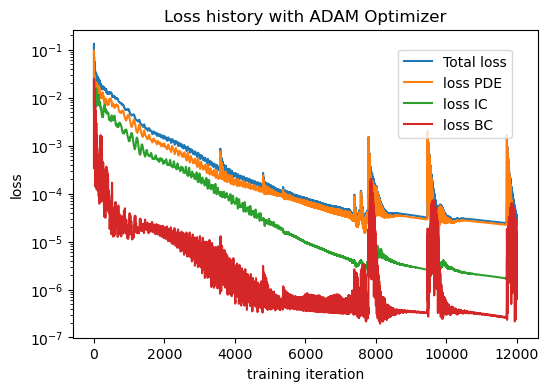

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.semilogy(loss_history, label="Total loss")
plt.semilogy(pde_history, label="loss PDE")
plt.semilogy(ic_history, label="loss IC")
plt.semilogy(bc_history, label="loss BC")
plt.xlabel("training iteration")
plt.title("Loss history with ADAM Optimizer")
plt.ylabel("loss")
# plt.grid(True)
plt.legend(loc=(0.7,0.65))
plt.show()

### Comparing the PINN predicted and analytical solutions (ADAM)

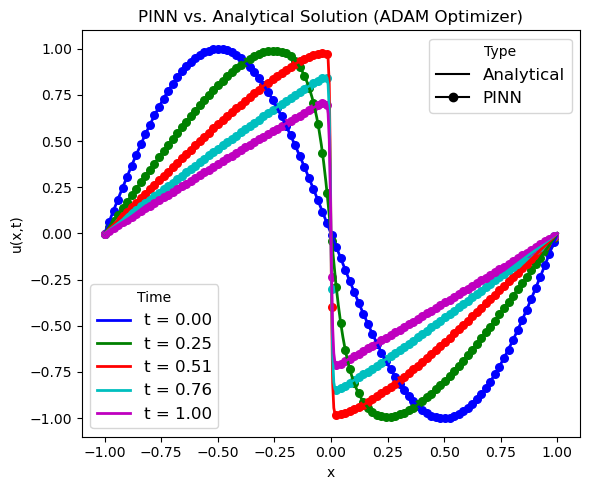

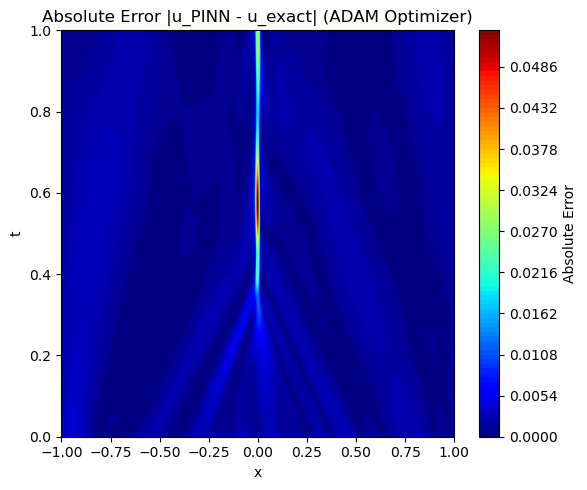

In [16]:
###############################################################
# Compare PINN prediction with analytical solution
###############################################################

model.eval()

# Evaluation grid
Nx_test = Nx
Nt_test = Nt

x = np.linspace(-1, 1, Nx_test)
t = np.linspace(0, 1, Nt_test)

# Meshgrid
X, T = np.meshgrid(x, t, indexing='ij')

# Convert to tensors
X_test = torch.tensor(X.reshape(-1,1), dtype=torch.float32, device=device)
T_test = torch.tensor(T.reshape(-1,1), dtype=torch.float32, device=device)

# Predict
with torch.no_grad():
    u_pred = model(torch.cat([X_test, T_test], dim=1))

u_pred = u_pred.cpu().numpy().reshape(Nx_test, Nt_test)

###############################################################
# Plot time snapshots
###############################################################

snapshot_indices = [0, 25, 50, 75, 99]
color_list = ['b', 'g', 'r', 'c', 'm', 'y', 'k']
plt.figure(figsize=(6,5))
for k,j in enumerate(snapshot_indices):
    plt.plot(x,u_quad[:,j],c=color_list[k],linewidth=2,label=f"t = {t[j]:.2f}")
    plt.scatter(x[::4],u_pred[::4,j],c=color_list[k],s=30)
leg_time = plt.legend(title="Time", loc='lower left',fontsize=12)
plt.gca().add_artist(leg_time)

sim_line = plt.plot([], [], 'k-', label='Analytical')[0]
ana_line = plt.plot([], [], c='k', marker='o', label='PINN')[0]
plt.legend(handles=[sim_line, ana_line], title="Type", loc='upper right',fontsize=12)
plt.ylabel("u(x,t)")
plt.title(f"PINN vs. Analytical Solution (ADAM Optimizer)")
plt.xlabel("x")
    # plt.grid(True)
plt.tight_layout()
plt.show()

###############################################################
# Evaluate Absoulute Error |u_PINN - u_exact|
###############################################################

error = np.abs(u_pred - u_quad)

plt.figure(figsize=(6,5))
plt.contourf(X,T,error,levels=100,cmap="jet")
plt.colorbar(label="Absolute Error")
plt.xlabel("x")
plt.ylabel("t")
plt.title("Absolute Error |u_PINN - u_exact| (ADAM Optimizer)")
plt.tight_layout()
plt.show()

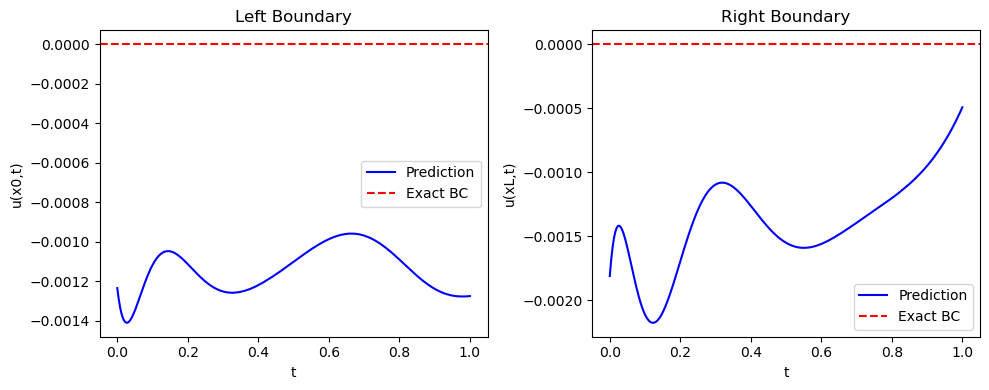

In [17]:
import matplotlib.pyplot as plt

model.eval()

with torch.no_grad():
    left = model(XT_left).cpu().numpy().squeeze()
    right = model(XT_right).cpu().numpy().squeeze()

t = t_bc.squeeze()

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(t, left, 'b', label='Prediction')
plt.axhline(0.0, color='r', linestyle='--', label='Exact BC')
plt.xlabel("t")
plt.ylabel("u(x0,t)")
plt.title("Left Boundary")
plt.legend()

plt.subplot(1,2,2)
plt.plot(t, right, 'b', label='Prediction')
plt.axhline(0.0, color='r', linestyle='--', label='Exact BC')
plt.xlabel("t")
plt.ylabel("u(xL,t)")
plt.title("Right Boundary")
plt.legend()

plt.tight_layout()
plt.show()

In [18]:
with torch.no_grad():
    left = model(XT_left)
    right = model(XT_right)

print(f"Left BC RMSE : {torch.sqrt(torch.mean(left**2)).item():.3e}")
print(f"Right BC RMSE: {torch.sqrt(torch.mean(right**2)).item():.3e}")

print(f"Left BC max error : {torch.max(torch.abs(left)).item():.3e}")
print(f"Right BC max error: {torch.max(torch.abs(right)).item():.3e}")

Left BC RMSE : 1.150e-03
Right BC RMSE: 1.426e-03
Left BC max error : 1.410e-03
Right BC max error: 2.177e-03


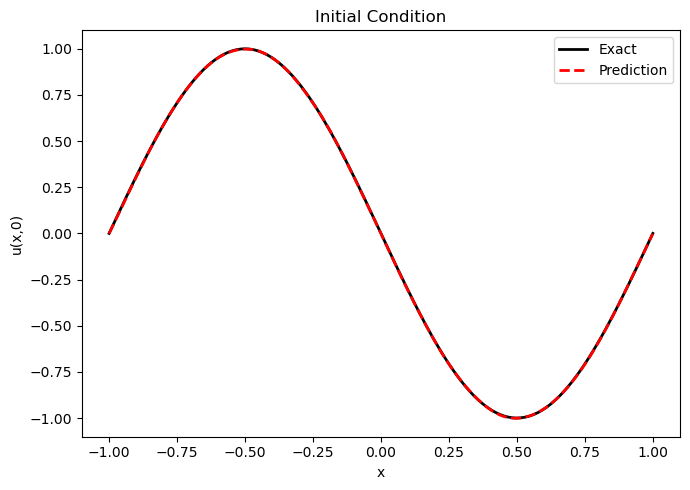

In [19]:
model.eval()

with torch.no_grad():
    u_pred = model(XT_ic).cpu().numpy().squeeze()

u_true = U_ic.cpu().numpy().squeeze()
x = XT_ic[:, 0].cpu().numpy()

plt.figure(figsize=(7,5))

plt.plot(x, u_true, 'k', lw=2, label='Exact')
plt.plot(x, u_pred, 'r--', lw=2, label='Prediction')

plt.xlabel('x')
plt.ylabel('u(x,0)')
plt.title('Initial Condition')
plt.legend()

plt.tight_layout()
plt.show()

In [20]:
with torch.no_grad():
    u_pred = model(XT_ic)

rmse = torch.sqrt(torch.mean((u_pred - U_ic)**2)).item()
max_err = torch.max(torch.abs(u_pred - U_ic)).item()
rel_l2 = (torch.norm(u_pred - U_ic) / torch.norm(U_ic)).item()

print(f"IC RMSE      : {rmse:.3e}")
print(f"IC Max Error : {max_err:.3e}")
print(f"IC Relative L2 Error : {rel_l2:.3e}")

IC RMSE      : 1.521e-03
IC Max Error : 4.102e-03
IC Relative L2 Error : 2.155e-03


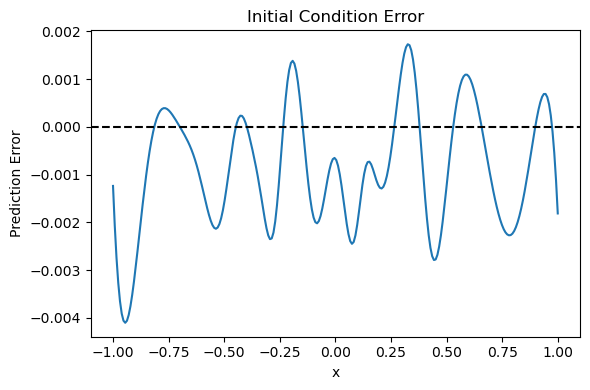

In [21]:
error = (u_pred - U_ic).cpu().numpy().squeeze()

plt.figure(figsize=(6,4))
plt.plot(x, error)
plt.axhline(0, color='k', linestyle='--')
plt.xlabel("x")
plt.ylabel("Prediction Error")
plt.title("Initial Condition Error")
plt.tight_layout()
plt.show()